In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns
from pathlib import Path
from scipy.stats import gaussian_kde
import time

import torch
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import zuko

import utils

## Data preparation

In [2]:
DATASET_PATH = Path("datasets/disasters_merged_all_feats.csv")
EVENT_GROUP = 'Flood'
RUN_PATH = Path(f"runs/MAF_{EVENT_GROUP.lower()}.pt")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [3]:

## Data Preparation
df = pd.read_csv(DATASET_PATH)
### Group by event type
df['EVENT_GROUP'].value_counts()
event_group_dfs = {
    'Hail': df[df['EVENT_GROUP'] == 'Hail'].drop(columns=['EVENT_GROUP', 'WIND_SPEED']),
    'Wind': df[df['EVENT_GROUP'] == 'Wind'].drop(columns=['EVENT_GROUP', 'HAIL_SIZE']),
    'Storm': df[df['EVENT_GROUP'] == 'Storm'].drop(columns=['EVENT_GROUP', 'HAIL_SIZE']),
    'Flood': df[df['EVENT_GROUP'] == 'Flood'].drop(columns=['EVENT_GROUP', 'HAIL_SIZE']),
    'Freeze': df[df['EVENT_GROUP'] == 'Freeze'].drop(columns=['EVENT_GROUP', 'HAIL_SIZE']),
    'Drought': df[df['EVENT_GROUP'] == 'Drought'].drop(columns=['EVENT_GROUP', 'HAIL_SIZE']),
    'Snow': df[df['EVENT_GROUP'] == 'Snow'].drop(columns=['EVENT_GROUP', 'HAIL_SIZE']),
    'Heat': df[df['EVENT_GROUP'] == 'Heat'].drop(columns=['EVENT_GROUP', 'HAIL_SIZE']),
    'Heavy Rain': df[df['EVENT_GROUP'] == 'Heavy Rain'].drop(columns=['EVENT_GROUP', 'HAIL_SIZE']),
    'Fog': df[df['EVENT_GROUP'] == 'Fog'].drop(columns=['EVENT_GROUP', 'HAIL_SIZE']),
    'Wildfire': df[df['EVENT_GROUP'] == 'Wildfire'].drop(columns=['EVENT_GROUP', 'HAIL_SIZE']),
    'Lightning': df[df['EVENT_GROUP'] == 'Lightning'].drop(columns=['EVENT_GROUP', 'HAIL_SIZE']),
    'Debris Flow': df[df['EVENT_GROUP'] == 'Debris Flow'].drop(columns=['EVENT_GROUP', 'HAIL_SIZE']),
    'Avalanche': df[df['EVENT_GROUP'] == 'Avalanche'].drop(columns=['EVENT_GROUP', 'HAIL_SIZE']),
}
event_group_dfs['Hail'].head()
df = event_group_dfs[EVENT_GROUP]
### Data normalization
TARGET_COLS = ["DAMAGES", "CASUALTIES"]

X_COLS = [
    'BEGIN_LAT', 'BEGIN_LON',
    'DURATION_HOURS', 'WIND_SPEED', # change with hail size for hail
    'TIME_DAY_SIN', 'TIME_DAY_COS', 'TIME_YEAR_NORM',
    'PRECIPITATION', 'TMIN', 'TMAX',
    'ELEVATION', 'SLOPE',
    'COV_BARREN', 'COV_CULTIVATED', 'COV_VEGETATION',
    'COV_FOREST', 'COV_WATER', 'COV_SNOW_ICE', 'COV_URBAN',
    'RIVER_DISTANCE', 'SEA_DISTANCE'
]
X = df[X_COLS].values.astype(np.float32)
Y = df[TARGET_COLS].values.astype(np.float32)
# targets log transformation
Y = np.log1p(Y)
# train-val-test split
X_train, X_temp, Y_train, Y_temp = train_test_split(X, Y, test_size=0.3, random_state=42)

X_val, X_test, Y_val, Y_test = train_test_split(X_temp, Y_temp, test_size=0.5, random_state=42)
# standardize features and targets
x_scaler = StandardScaler()
y_scaler = StandardScaler()

X_train = x_scaler.fit_transform(X_train)
X_val   = x_scaler.transform(X_val)
X_test  = x_scaler.transform(X_test)

Y_train = y_scaler.fit_transform(Y_train)
Y_val   = y_scaler.transform(Y_val)
Y_test  = y_scaler.transform(Y_test)

### Dataset split
# conversion to tensors and move to device
X_train = torch.tensor(X_train).to(device)
Y_train = torch.tensor(Y_train).to(device)

X_val = torch.tensor(X_val).to(device)
Y_val = torch.tensor(Y_val).to(device)

X_test = torch.tensor(X_test).to(device)
Y_test = torch.tensor(Y_test).to(device)

# data loaders
train_ds = TensorDataset(X_train, Y_train)
val_ds   = TensorDataset(X_val, Y_val)
test_ds   = TensorDataset(X_val, Y_val)

## Model

### Model definition

In [4]:
EPOCHS = 250
BATCH_SIZE = 512
BASE_LR = 1e-3

# find warmup steps as function of epochs and dataset size
WARMUP_STEPS = int(0.1 * (len(train_ds) // BATCH_SIZE) * EPOCHS)

In [5]:
X_DIM = X_train.shape[1]
Y_DIM = Y_train.shape[1]

flow = zuko.flows.MAF(
    features=Y_DIM,
    context=X_DIM,
    transforms=6,
    hidden_features=[256, 256],
    randperm=False # Keep DAMAGES -> CASUALITIES order
)

In [6]:
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_ds, batch_size=BATCH_SIZE)
test_loader   = DataLoader(test_ds, batch_size=BATCH_SIZE)

In [7]:
flow = flow.to(device)

optimizer = torch.optim.Adam(flow.parameters(), lr=BASE_LR, weight_decay=1e-5)

warmup = torch.optim.lr_scheduler.LinearLR(
    optimizer,
    start_factor=0.1,
    total_iters=WARMUP_STEPS
)
cosine = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=EPOCHS * len(train_loader) - WARMUP_STEPS,
    eta_min=1e-5
)
scheduler = torch.optim.lr_scheduler.SequentialLR(
    optimizer,
    schedulers=[warmup, cosine],
    milestones=[WARMUP_STEPS]
)

scaler = torch.amp.GradScaler(device=device)

ema = torch.optim.swa_utils.AveragedModel(
    flow,
    avg_fn=lambda averaged, model, num_averaged: 0.999 * averaged + 0.001 * model
)

In [8]:
print(f"MAF model created with {sum(p.numel() for p in flow.parameters())} parameters")

MAF model created with 437784 parameters


In [9]:
class TrainingHistory:
    def __init__(self):
        self.train_losses = []
        self.val_losses = []
        self.lrs = []

In [38]:
history = TrainingHistory()
best_val_loss = np.inf
global_step = 0

for epoch in range(EPOCHS):
    t0 = time.time()
    flow.train()
    train_loss = 0

    for x, y in train_loader:
        x = x.to(device)
        y = y.to(device)

        optimizer.zero_grad(set_to_none=True)

        #with torch.amp.autocast(device.type):
        loss = -flow(x).log_prob(y).mean()

        loss.backward()

        #scaler.scale(loss).backward()

        # gradient clipping
        #scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(flow.parameters(), 1.0)

        #scaler.step(optimizer)
        #scaler.update()
        optimizer.step()

        scheduler.step()

        ema.update_parameters(flow)

        train_loss += loss.item()
        global_step += 1

    train_loss /= len(train_loader)

    # ---------- Validation ----------
    flow.eval()
    val_loss = 0

    with torch.no_grad():
        for x, y in val_loader:
            x = x.to(device)
            y = y.to(device)
            loss = -flow(x).log_prob(y).mean()
            val_loss += loss.item()

    val_loss /= len(val_loader)

    history.train_losses.append(train_loss)
    history.val_losses.append(val_loss)
    history.lrs.append(optimizer.param_groups[0]["lr"])

    print(
        f"Epoch {epoch:03d} | "
        f"Time {time.time()-t0:.2f}s | "
        f"Train NLL {train_loss:.3f} | "
        f"Val NLL {val_loss:.3f} | "
        f"LR {optimizer.param_groups[0]['lr']:.2e}"
    )

    # Save EMA weights (better than raw model)
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(ema.module.state_dict(), RUN_PATH)


Epoch 000 | Time 1.69s | Train NLL 2.753 | Val NLL 2.564 | LR 1.37e-04
Epoch 001 | Time 1.64s | Train NLL 2.119 | Val NLL 1.203 | LR 1.73e-04
Epoch 002 | Time 1.58s | Train NLL 147.830 | Val NLL 0.283 | LR 2.10e-04
Epoch 003 | Time 1.58s | Train NLL 25.149 | Val NLL 0.869 | LR 2.46e-04
Epoch 004 | Time 1.60s | Train NLL -1.658 | Val NLL -0.110 | LR 2.83e-04
Epoch 005 | Time 1.54s | Train NLL -2.080 | Val NLL -1.974 | LR 3.19e-04
Epoch 006 | Time 1.62s | Train NLL -2.375 | Val NLL -1.949 | LR 3.56e-04
Epoch 007 | Time 1.80s | Train NLL -2.420 | Val NLL -2.155 | LR 3.92e-04
Epoch 008 | Time 1.52s | Train NLL -2.540 | Val NLL -2.343 | LR 4.29e-04
Epoch 009 | Time 1.54s | Train NLL -2.625 | Val NLL -1.181 | LR 4.65e-04
Epoch 010 | Time 1.54s | Train NLL -2.712 | Val NLL -1.500 | LR 5.02e-04
Epoch 011 | Time 1.65s | Train NLL -2.896 | Val NLL 1.683 | LR 5.38e-04
Epoch 012 | Time 1.60s | Train NLL -3.130 | Val NLL -1.031 | LR 5.75e-04
Epoch 013 | Time 1.55s | Train NLL -3.020 | Val NLL 15.50

In [10]:
flow.load_state_dict(torch.load(RUN_PATH, weights_only=True))
flow.eval()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
flow = flow.to(device)

NameError: name 'history' is not defined

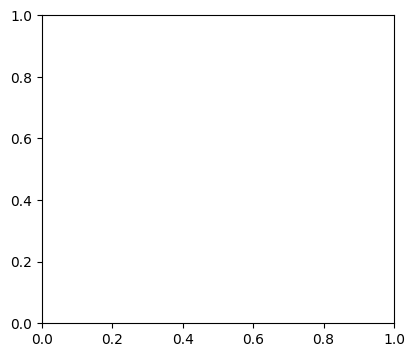

In [11]:
# plot training curves (loss and learning rate)
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(history.train_losses, label='Train Loss')
plt.plot(history.val_losses, label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('NLL')
plt.title('Loss Curve')
plt.legend()
plt.subplot(1,2,2)
plt.plot(history.lrs, label='Learning Rate')
plt.xlabel('Epoch')
plt.ylabel('LR')
plt.title('LR Schedule')
plt.legend()
plt.tight_layout()
plt.show()


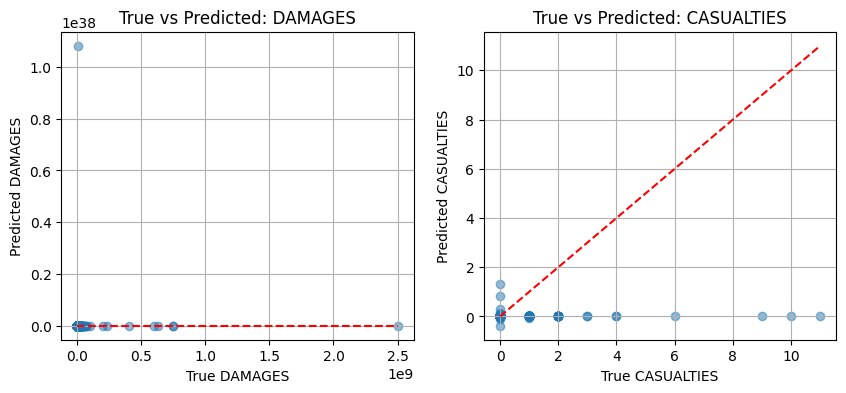

In [12]:
utils.run_inference_and_plot(flow, test_loader, y_scaler, TARGET_COLS, device)

In [13]:
def compute_avg_true_pred_diff(flow, test_loader, y_scaler):
    flow.eval()
    y_true = []
    y_pred = []
    with torch.no_grad():
        for x_batch, y_batch in test_loader:
            x_batch = x_batch.to(device)
            y_batch = y_batch.to(device)
            dist = flow(x_batch)
            y_hat = dist.sample().squeeze()
            y_true.append(y_batch.cpu())
            y_pred.append(y_hat.cpu())
    y_true = torch.cat(y_true, dim=0).numpy()
    y_pred = torch.cat(y_pred, dim=0).numpy()
    if y_true.ndim == 1:
        y_true = y_true.reshape(-1, 1)
    if y_pred.ndim == 1:
        y_pred = y_pred.reshape(-1, 1)
    y_true = y_scaler.inverse_transform(y_true)
    y_pred = y_scaler.inverse_transform(y_pred)
    y_pred = np.expm1(np.clip(y_pred, -20, None))
    y_true = np.expm1(np.clip(y_true, -20, None))
    avg_diff_damages = np.mean(np.abs(y_true[:, 0] - y_pred[:, 0]))
    print(f"Average absolute difference in {TARGET_COLS[0]}: {avg_diff_damages:.2f}")

compute_avg_true_pred_diff(flow, test_loader, y_scaler)

Average absolute difference in DAMAGES: 1330793422680852084237008896.00
